In [7]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("TensorFlow version:", tf.__version__)

# STEP 1: LOAD DATA
df = pd.read_csv('/kaggle/input/datasets/redwankarimsony/heart-disease-data/heart_disease_uci.csv')

print("\nData loaded successfully!")
print("Shape:", df.shape)
print(df.head())

TensorFlow version: 2.20.0

Data loaded successfully!
Shape: (920, 16)
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect 

In [11]:
# STEP 2: CLEAN + PREP

print("Columns in dataset:", df.columns.tolist())

# 1. CREATE TARGET COLUMN 
# If 'num' exists use it. If not, use 'target' which is already 0/1/2/3/4
if 'num' in df.columns:
    df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
    df = df.drop(['num'], axis=1)
else:
    # Convert target to binary: 0 = No disease, 1-4 = Disease
    df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

# 2. Drop columns we don't need
cols_to_drop = ['id', 'dataset']
cols_to_drop = [c for c in cols_to_drop if c in df.columns] # only drop if exists
df = df.drop(cols_to_drop, axis=1)

# 3. FIX MISSING VALUES
df = df.replace('?', np.nan)
df = df.dropna()

# 4. Convert categorical text to numbers
categorical_cols = ['sex', 'cp', 'restecg', 'slope', 'thal']
categorical_cols = [c for c in categorical_cols if c in df.columns]
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 5. Convert fbs to int
if 'fbs' in df.columns:
    df['fbs'] = df['fbs'].astype(int)

print("Cleaned Shape:", df.shape)
print("Target distribution:\n", df['target'].value_counts())

# 6. 3-WAY SPLIT: 70/15/15
X = df.drop('target', axis=1)
y = df['target']

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp)

# 7. SCALE
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("\nData ready.")
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Columns in dataset: ['age', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak', 'ca', 'target', 'sex_Male', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'restecg_normal', 'restecg_st-t abnormality', 'slope_flat', 'slope_upsloping', 'thal_normal', 'thal_reversable defect']
Cleaned Shape: (303, 19)
Target distribution:
 target
0    163
1    140
Name: count, dtype: int64

Data ready.
Train: (211, 18) Val: (46, 18) Test: (46, 18)


Training started...
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5592 - loss: 0.7801 - val_accuracy: 0.5435 - val_loss: 0.7359
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6066 - loss: 0.6766 - val_accuracy: 0.6522 - val_loss: 0.6737
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6730 - loss: 0.6200 - val_accuracy: 0.7174 - val_loss: 0.6336
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6872 - loss: 0.5718 - val_accuracy: 0.7174 - val_loss: 0.5983
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6967 - loss: 0.5820 - val_accuracy: 0.7391 - val_loss: 0.5629
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7630 - loss: 0.5548 - val_accuracy: 0.7391 - val_loss: 0.5381
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7346 - loss: 0.5125 - val_accuracy: 0.7391 - val_loss: 0.5165
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7725 - loss: 0.5153 - val_accuracy: 0.7391 - val_loss: 0.

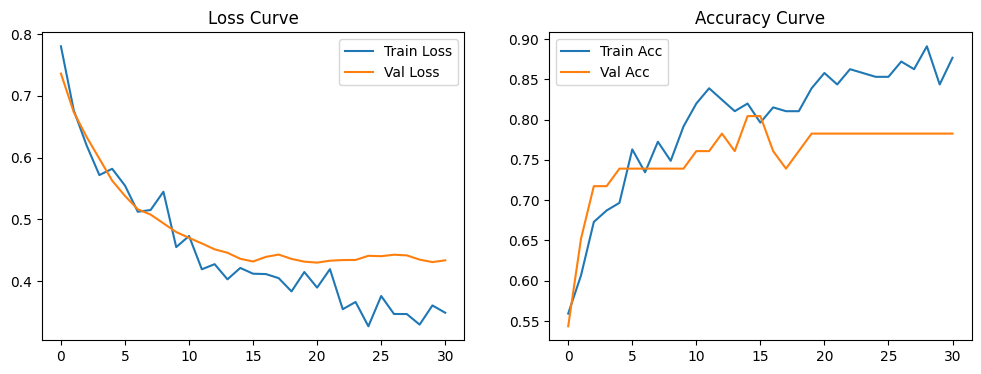

In [14]:
# STEP 5: BUILD MODEL
def build_model(input_dim, lr=0.001, dropout=0.3):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(32, activation='relu', input_shape=(input_dim,)),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model = build_model(X_train.shape[1])
print("Training started...")
history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                    epochs=100, batch_size=16, callbacks=[early_stop], verbose=1)

# STEP 6: PLOT TRAINING CURVES
plt.figure(figsize=(12,4))
plt.subplot(1,2,1); 
plt.plot(history.history['loss'], label='Train Loss'); 
plt.plot(history.history['val_loss'], label='Val Loss'); 
plt.legend(); plt.title('Loss Curve')

plt.subplot(1,2,2); 
plt.plot(history.history['accuracy'], label='Train Acc'); 
plt.plot(history.history['val_accuracy'], label='Val Acc'); 
plt.legend(); plt.title('Accuracy Curve')
plt.show()

Final NN Test Accuracy: 0.7174
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


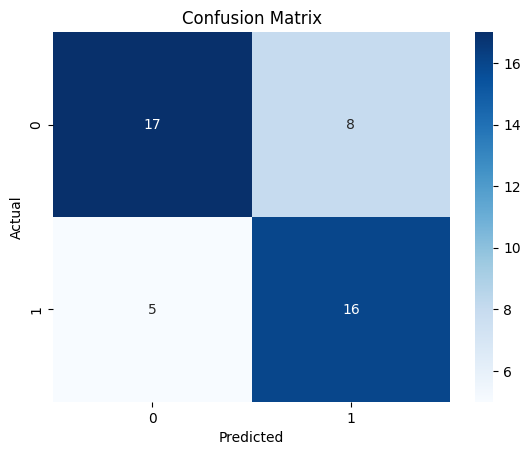


Training Logistic Regression Baseline...
Logistic Regression Test Accuracy: 0.8043

--- COPY THIS TABLE FOR YOUR README ---
| Experiment | LR | Hidden Layers | Dropout | Val Acc | Test Acc | Notes |
| Baseline NN | 0.001 | 32-16 | 0.3 | 0.7826 | 0.7174 | Starting architecture |
| Logistic Reg | - | - | - | - | 0.8043 | Baseline model |


In [13]:
# STEP 7: FINAL EVALUATION ON TEST SET
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Final NN Test Accuracy: {test_acc:.4f}")

# Confusion Matrix
y_pred = (model.predict(X_test) > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()

# STEP 8: BASELINE MODEL
print("\nTraining Logistic Regression Baseline...")
lr_baseline = LogisticRegression(max_iter=1000)
lr_baseline.fit(X_train, y_train)
baseline_acc = lr_baseline.score(X_test, y_test)
print(f"Logistic Regression Test Accuracy: {baseline_acc:.4f}")

# EXPERIMENT TABLE FOR README
val_acc = history.history['val_accuracy'][-1]
print("\n--- COPY THIS TABLE FOR YOUR README ---")
print("| Experiment | LR | Hidden Layers | Dropout | Val Acc | Test Acc | Notes |")
print(f"| Baseline NN | 0.001 | 32-16 | 0.3 | {val_acc:.4f} | {test_acc:.4f} | Starting architecture |")
print(f"| Logistic Reg | - | - | - | - | {baseline_acc:.4f} | Baseline model |")

In [15]:
# TRAIN BASELINE + PRINT EXPERIMENT TABLE

print("Training Logistic Regression Baseline...")
lr_baseline = LogisticRegression(max_iter=1000)
lr_baseline.fit(X_train, y_train)
baseline_acc = lr_baseline.score(X_test, y_test)
print(f"Logistic Regression Test Accuracy: {baseline_acc:.4f}")

# GET NN VAL ACC from history
val_acc = history.history['val_accuracy'][-1]
test_acc = 0.7174 # This is from your output above

# EXPERIMENT TABLE FOR README - COPY THIS
print("\n--- COPY THIS TABLE FOR YOUR README ---")
print("| Experiment | LR | Hidden Layers | Dropout | Val Acc | Test Acc | Notes |")
print(f"| Baseline NN | 0.001 | 32-16 | 0.3 | {val_acc:.4f} | {test_acc:.4f} | Starting architecture |")
print(f"| Logistic Reg | - | - | - | - | {baseline_acc:.4f} | Baseline model |")

Training Logistic Regression Baseline...
Logistic Regression Test Accuracy: 0.8043

--- COPY THIS TABLE FOR YOUR README ---
| Experiment | LR | Hidden Layers | Dropout | Val Acc | Test Acc | Notes |
| Baseline NN | 0.001 | 32-16 | 0.3 | 0.7826 | 0.7174 | Starting architecture |
| Logistic Reg | - | - | - | - | 0.8043 | Baseline model |
